# Analysis of Results

## Analysis of GSM8K Results

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import os

def separate_strings(str):
    match = re.match(r"([a-zA-Z]+)(.*)", str)
    return match.groups()

def convert_size_format(str):
    if 'b' in str:
        return float(str.split('b')[0])
    
    if 'm' in str:
        return float(str.split('m')[0])/1_000

def make_final_table(path, bn, metric):
    latency = pd.DataFrame()

    files = glob.glob(os.path.join(path, f"*{bn}.csv"))
    scores = pd.read_csv(f'/Users/radia78/Projects/CS839/final_project/scores/{bn}_scores.csv')

    for file in files:
        temp_df = pd.read_csv(file)
        method_id = file.split('/')[-1].split('_')
        temp_df['method'] = method_id[0]
        name, size = separate_strings(method_id[1])
        temp_df['model'] = name
        temp_df['size'] = convert_size_format(size.lower())
            
        latency = pd.concat([latency, temp_df[['method', 'model', 'wall_time', 'size']]], axis=0)

    scores['method'] = scores['filename'].apply(lambda row: row.split('_')[0])
    scores['size'] = scores['filename'].apply(lambda row: convert_size_format(separate_strings(row.split('_')[1])[1].lower()))
    scores['model'] = scores['filename'].apply(lambda row: separate_strings(row.split('_')[1])[0])
    scores = scores[['method', 'model', 'size', metric]]

    # Qwen with 270m as baseline
    latency = latency.groupby(['method', 'model', 'size']).mean().reset_index()
    gemma = pd.DataFrame()
    gemma_baseline = latency[(latency['model'] == 'gemma') & (latency['method'] == 'sampling') & (latency['size'] == 0.27)]['wall_time'].iloc[0]
    gemma['size'] = latency[latency['model'] == 'gemma']['size']
    gemma['wall_time'] = np.round(latency[latency['model'] == 'gemma']['wall_time'].div(gemma_baseline) - 1, 2) * 100
    gemma['method'] = latency[latency['model'] == 'gemma']['method']
    gemma['model'] = 'gemma'
    gemma = gemma[(gemma['method'] != 'sampling') | (gemma['size'] != 1.0)]

    # Qwen with 0.6B as baseline
    qwen = pd.DataFrame()
    qwen_baseline = latency[(latency['model'] == 'qwen') & (latency['method'] == 'sampling') & (latency['size'] == 0.6)]['wall_time'].iloc[0]
    qwen['size'] = latency[latency['model'] == 'qwen']['size']
    qwen['wall_time'] = np.round(latency[latency['model'] == 'qwen']['wall_time'].div(qwen_baseline) - 1, 2) * 100
    qwen['method'] = latency[latency['model'] == 'qwen']['method']
    qwen['model'] = 'qwen'
    qwen = qwen[(qwen['method'] != 'sampling') | (qwen['size'] != 1.7)]

    df = pd.concat([gemma, qwen])
    df = pd.merge(df, scores, on=['size', 'method', 'model'])

    return df

PATH = 'cs839_test_a100'

gsm8k = make_final_table(
    path=PATH,
    bn='gsm8k',
    metric='accuracy'
)

wmt = make_final_table(
    path=PATH,
    bn='wmt_de_en',
    metric='score'
)

mbpp = make_final_table(
    path=PATH,
    bn='mbpp',
    metric='accuracy'
)

cnn = make_final_table(
    path=PATH,
    bn='cnn_dm',
    metric='rougeL'
)

squad = make_final_table(
    path=PATH,
    bn='squad_2',
    metric='f1'
)

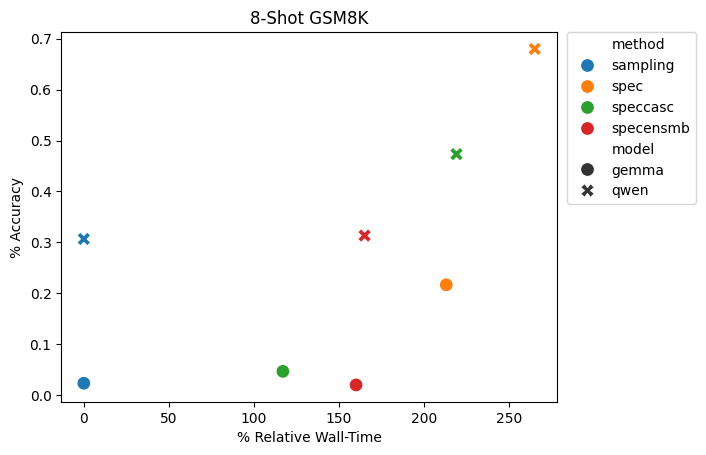

In [2]:
sns.scatterplot(x='wall_time', y='accuracy', data=gsm8k, style='model', hue='method', s=100.0)
plt.xlabel("% Relative Wall-Time")
plt.ylabel("% Accuracy")
plt.title("8-Shot GSM8K")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="")
plt.show()

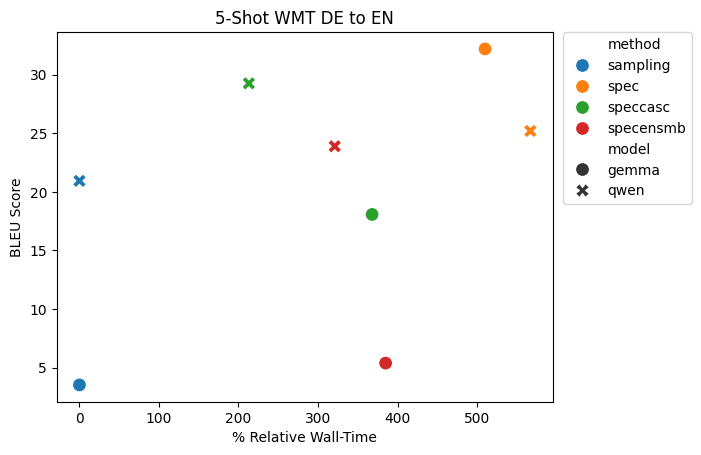

In [3]:
sns.scatterplot(x='wall_time', y='score', data=wmt, style='model', hue='method', s=100)
plt.xlabel("% Relative Wall-Time")
plt.ylabel("BLEU Score")
plt.title("5-Shot WMT DE to EN")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="")
plt.show()

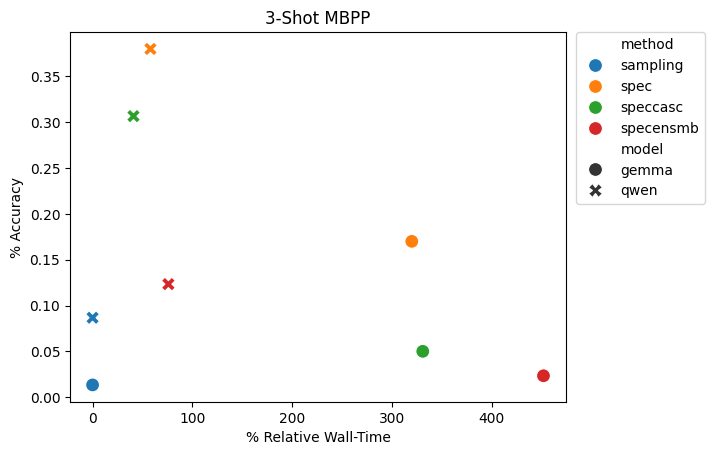

In [4]:
sns.scatterplot(x='wall_time', y='accuracy', data=mbpp, style='model', hue='method', s=100)
plt.xlabel("% Relative Wall-Time")
plt.ylabel("% Accuracy")
plt.title("3-Shot MBPP")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="")
plt.show()

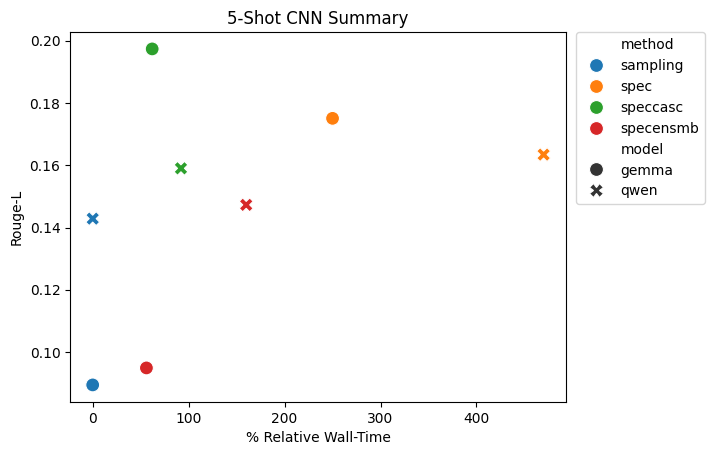

In [5]:
sns.scatterplot(x='wall_time', y='rougeL', data=cnn, style='model', hue='method', s=100)
plt.xlabel("% Relative Wall-Time")
plt.ylabel("Rouge-L")
plt.title("5-Shot CNN Summary")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="")
plt.show()

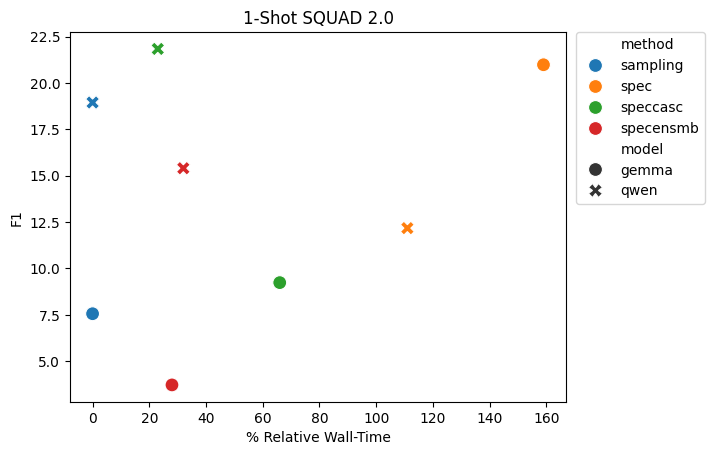

In [6]:
sns.scatterplot(x='wall_time', y='f1', data=squad, style='model', hue='method', s=100)
plt.xlabel("% Relative Wall-Time")
plt.ylabel("F1")
plt.title("1-Shot SQUAD 2.0")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="")
plt.show()